# Nykaa Marketing Campaign Performance Analysis

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Load Dataset

In [2]:
df = pd.read_csv("nykaa_campaign_data.csv")

## Initial Data Exploration

In [3]:
df.shape

(55555, 16)

In [4]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024


## Data Quality Assessment

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

In [6]:
df.isnull().sum()

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [7]:
df.duplicated().sum()

0

## Understanding Categorical Variables

In [8]:
df['Campaign_Type'].value_counts()

Campaign_Type
Influencer      11134
Paid Ads        11116
Social Media    11114
Email           11112
SEO             11079
Name: count, dtype: int64

In [9]:
df['Target_Audience'].value_counts()

Target_Audience
Working Women            11224
Premium Shoppers         11182
Tier 2 City Customers    11100
College Students         11078
Youth                    10971
Name: count, dtype: int64

In [10]:
df['Language'].value_counts()

Language
Hindi      13986
Tamil      13884
English    13874
Bengali    13811
Name: count, dtype: int64

In [11]:
df['Customer_Segment'].value_counts()

Customer_Segment
College Students         11293
Working Women            11123
Youth                    11088
Premium Shoppers         11059
Tier 2 City Customers    10992
Name: count, dtype: int64

In [12]:
df['Channel_Used'].nunique()

156

## Marketing KPI Analysis

In [13]:
df['Revenue'].sum()

28656364282

In [14]:
df['Conversions'].sum()

57380922

In [15]:
df['Clicks'].sum()

260445757

In [16]:
df['Impressions'].sum()

3060407471

In [17]:
df['ROI'].mean()

2.713806858068581

In [18]:
ctr = (df['Clicks'].sum() /
       df['Impressions'].sum()) * 100

print(ctr)

8.510166030763816


In [19]:
conversion_rate = (
    df['Conversions'].sum() /
    df['Clicks'].sum()
) * 100

print(conversion_rate)

22.0318129429154


In [20]:
revenue_per_conversion = (
    df['Revenue'].sum() /
    df['Conversions'].sum()
)

print(revenue_per_conversion)

499.40578302314486


## Campaign Performance Analysis

### Revenue Analysis by Customer Segment

In [21]:
df.groupby('Campaign_Type')['Revenue'].sum().sort_values(ascending=False)

Campaign_Type
Influencer      5769064044
Social Media    5751837620
Paid Ads        5751468983
SEO             5698831847
Email           5685161788
Name: Revenue, dtype: int64

### ROI Analysis by Campaign Type

In [22]:
df.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False)

Campaign_Type
Social Media    2.754784
Paid Ads        2.722275
SEO             2.709630
Influencer      2.699687
Email           2.682663
Name: ROI, dtype: float64

In [23]:
df.groupby('Campaign_Type')['Conversions'].sum().sort_values(ascending=False)

Campaign_Type
Social Media    11595675
Influencer      11563919
Email           11425766
Paid Ads        11425573
SEO             11369989
Name: Conversions, dtype: int64

In [24]:
df.groupby('Customer_Segment')['Revenue'].sum().sort_values(ascending=False)

Customer_Segment
Working Women            5811927015
College Students         5799502690
Premium Shoppers         5709910379
Tier 2 City Customers    5691846274
Youth                    5643177924
Name: Revenue, dtype: int64

In [25]:
df.groupby('Customer_Segment')['ROI'].mean().sort_values(ascending=False)

Customer_Segment
Working Women            2.771055
Premium Shoppers         2.720461
College Students         2.699205
Tier 2 City Customers    2.699197
Youth                    2.679097
Name: ROI, dtype: float64

In [26]:
df.groupby('Language')['Revenue'].sum().sort_values(ascending=False)

Language
Hindi      7242728156
Tamil      7151812108
English    7131128736
Bengali    7130695282
Name: Revenue, dtype: int64

### Engagement Analysis

In [27]:
df.groupby('Campaign_Type')['Engagement_Score'].mean().sort_values(ascending=False)

Campaign_Type
Influencer      13.861539
Social Media    13.845957
Paid Ads        13.751833
Email           13.747823
SEO             13.713328
Name: Engagement_Score, dtype: float64

## Data Visualization

### Revenue by Campaign Type

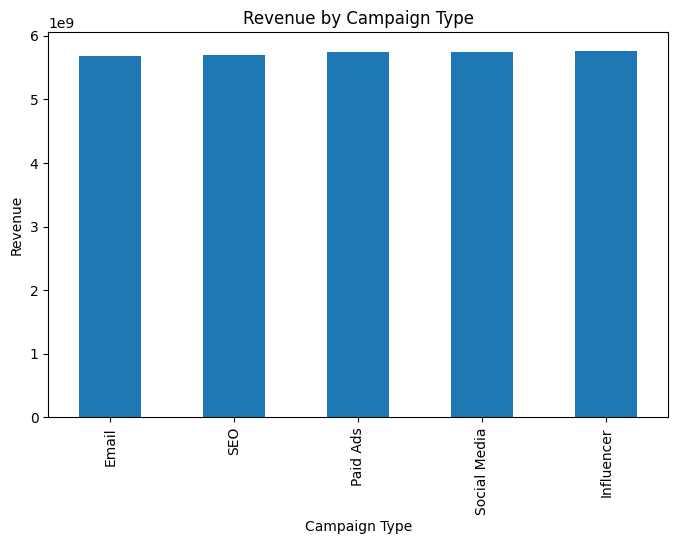

In [28]:
revenue_campaign = df.groupby(
    'Campaign_Type'
)['Revenue'].sum().sort_values()

plt.figure(figsize=(8,5))

revenue_campaign.plot(kind='bar')

plt.title('Revenue by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Revenue')

plt.show()

### Average ROI by Campaign Type

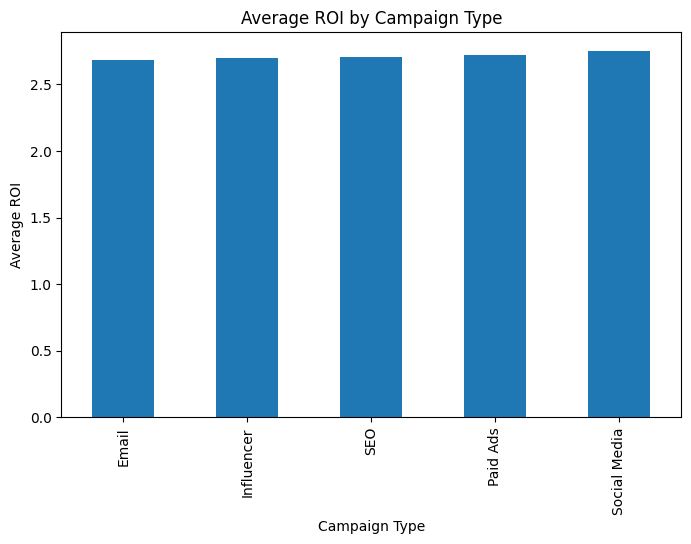

In [29]:
roi_campaign = df.groupby(
    'Campaign_Type'
)['ROI'].mean().sort_values()

plt.figure(figsize=(8,5))

roi_campaign.plot(kind='bar')

plt.title('Average ROI by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Average ROI')

plt.show()

### Revenue by Customer Segment

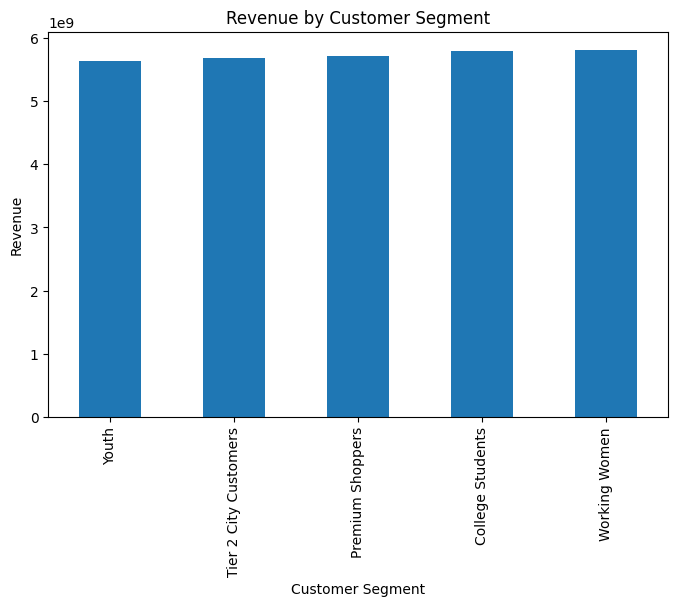

In [30]:
segment_revenue = df.groupby(
    'Customer_Segment'
)['Revenue'].sum().sort_values()

plt.figure(figsize=(8,5))

segment_revenue.plot(kind='bar')

plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue')

plt.show()

### Revenue by Language

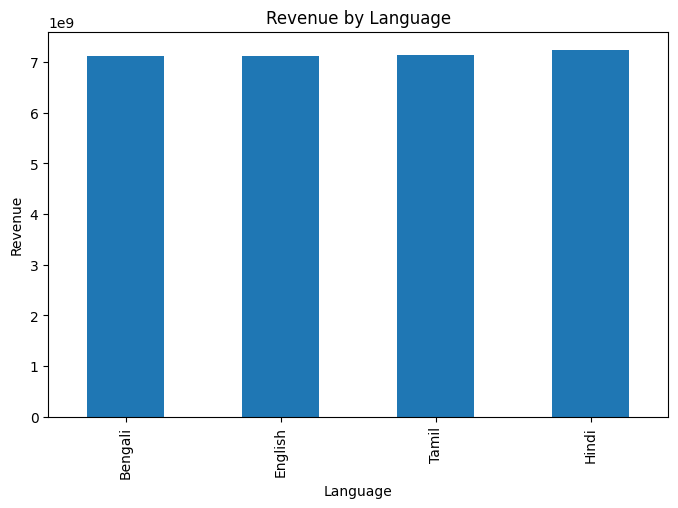

In [ ]:
language_revenue = df.groupby(
    'Language'
)['Revenue'].sum().sort_values()

plt.figure(figsize=(8,5))

language_revenue.plot(kind='bar')

plt.title('Revenue by Language')
plt.xlabel('Language')
plt.ylabel('Revenue')

plt.show()

### Campaign Type Distribution

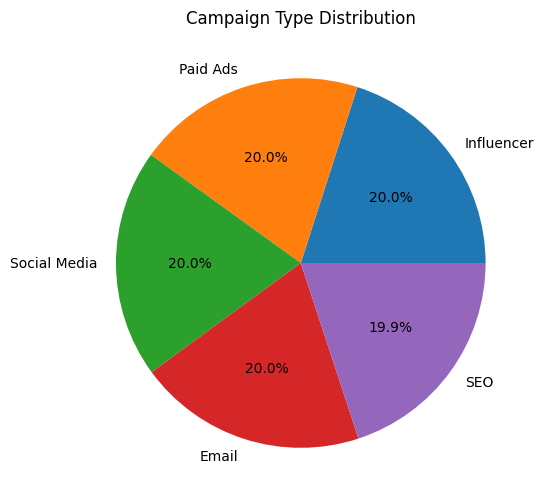

In [32]:
df['Campaign_Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Campaign Type Distribution')

plt.ylabel('')

plt.show()

# Business Insights

1. Influencer campaigns generated the highest revenue.

2. Social Media campaigns delivered the highest ROI.

3. Social Media campaigns produced the highest conversions.

4. Working Women generated the highest revenue and ROI.

5. Hindi campaigns generated the highest revenue.

6. Influencer campaigns achieved the highest engagement score.

7. The average campaign ROI was 2.71, indicating strong marketing performance.

8. The overall conversion rate exceeded 22%, reflecting effective campaign targeting.


## Export Dataset for Power BI

In [33]:
powerbi_df = df.drop(
    'Campaign_ID',
    axis=1
)

powerbi_df.to_csv(
    'marketing_campaign_cleaned.csv',
    index=False
)